## Analyzation of GraphCast_small Forecast for the 18th February 2022 22:00

In [2]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
import cartopy.feature as cfeature


## Graph for Wind Speed 18-02-2018 22:00 UTC

In [21]:
def plot_wind_speed_comparison(
    predictions_path: str,
    input_path: str,
    lon_min: float = 7.625,
    lon_max: float = 10.625,
    lat_min: float = 53.125,
    lat_max: float = 55.125,
    grid_spacing: float = 0.25,
    time_index: int = -1,
    time_label: str = None
):
    """
    Plot observed vs. predicted wind speed over a specified region.

    Parameters:
        predictions_path (str): Path to the prediction NetCDF file.
        input_path (str): Path to the ERA5 ground truth NetCDF file.
        lon_min, lon_max, lat_min, lat_max (float): Bounding box coordinates.
        grid_spacing (float): Spacing for lat/lon gridlines.
        time_index (int): Index for the time step to compare (default: -1 for last).
        time_label (str, optional): Label for the time in plot titles.
    """
    # Load datasets
    with xr.open_dataset(predictions_path) as ds:
        predictions = ds.load()

    with xr.open_dataset(input_path) as ds:
        example_batch = ds.load()

    # Select wind components at desired time index
    u_true = example_batch["10m_u_component_of_wind"].isel(time=time_index).squeeze("batch")
    v_true = example_batch["10m_v_component_of_wind"].isel(time=time_index).squeeze("batch")
    wind_true = np.sqrt(u_true**2 + v_true**2)

    u_pred = predictions["10m_u_component_of_wind"].isel(time=time_index).squeeze("batch")
    v_pred = predictions["10m_v_component_of_wind"].isel(time=time_index).squeeze("batch")
    wind_pred = np.sqrt(u_pred**2 + v_pred**2)

    # Region slice
    region = dict(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))
    true_region = wind_true.sel(**region)
    pred_region = wind_pred.sel(**region)

    # Fixed color scale
    vmin, vmax = 11, 21
    time_label = time_label or "Unknown UTC"
    titles = [f"Observed Wind Speed at {time_label}", f"Predicted Wind Speed at {time_label}"]

    # Plotting
    fig, axs = plt.subplots(1, 2, figsize=(14, 8), subplot_kw={'projection': ccrs.Mercator()})


    for ax, data, title in zip(axs, [true_region, pred_region], titles):
        im = data.plot.pcolormesh(
            ax=ax, cmap="viridis", add_colorbar=False, transform=ccrs.PlateCarree(),
            vmin=vmin, vmax=vmax
        )
        ax.set_title(title)

        # Round to avoid floating-point artifacts
        extent = [round(lon_min, 3), round(lon_max, 3), round(lat_min, 3), round(lat_max, 3)]
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        ax.set_aspect('equal', adjustable='box')


        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}
        # gl.xlocator = mticker.MultipleLocator(grid_spacing)
        # gl.ylocator = mticker.MultipleLocator(grid_spacing)

        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.3)

        # Add city markers
        city_coords = {
            "Hamburg": (10.0, 53.55),
            "Kiel": (10.1228, 54.3233),
            "Flensburg": (9.4469, 54.7939),
            "Cuxhaven": (8.6942, 53.8647),
            "Büsum": (8.8581, 54.1291),
            "Bremen": (8.8012, 53.0793),
            "Bremerhaven": (8.5809, 53.5396),
        }

        for city, (lon, lat) in city_coords.items():
            ax.plot(lon, lat, 'wo', markersize=5, transform=ccrs.PlateCarree())
            ax.text(lon + 0.05, lat, city, color='white', fontsize=9, transform=ccrs.PlateCarree())

    # Shared colorbar
    cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.025, pad=0.02)
    cbar.set_label("10m Wind Speed (m/s)")

    plt.subplots_adjust(wspace=0.15, right=0.87)
    plt.show()

### Small

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_17421/656424945.py:24: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  with xr.open_dataset(predictions_path) as ds:


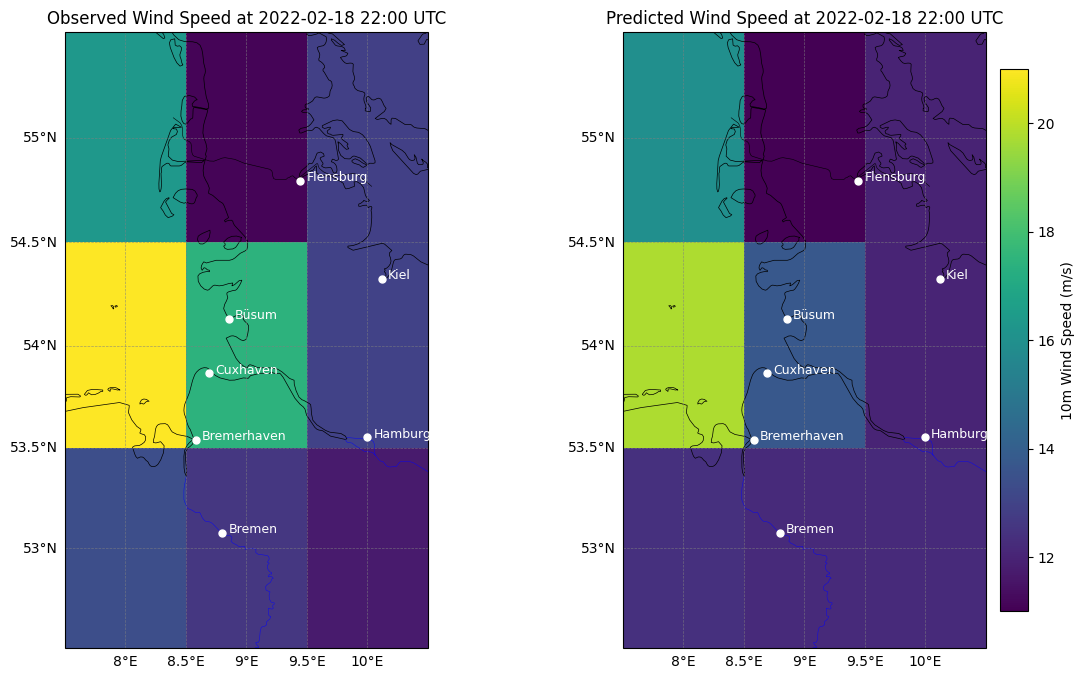

In [22]:
plot_wind_speed_comparison(
    predictions_path="../data/prediction_zeynep_22/predictions/zeynep_22_prediction_graphcast_small.nc",
    input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc",
    lon_min=7.5,
    lon_max=10.5,
    lat_min=52.5,
    lat_max=55.5,
    grid_spacing=0.5,
    time_label="2022-02-18 22:00 UTC"
)

### Operational

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_17421/656424945.py:24: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  with xr.open_dataset(predictions_path) as ds:


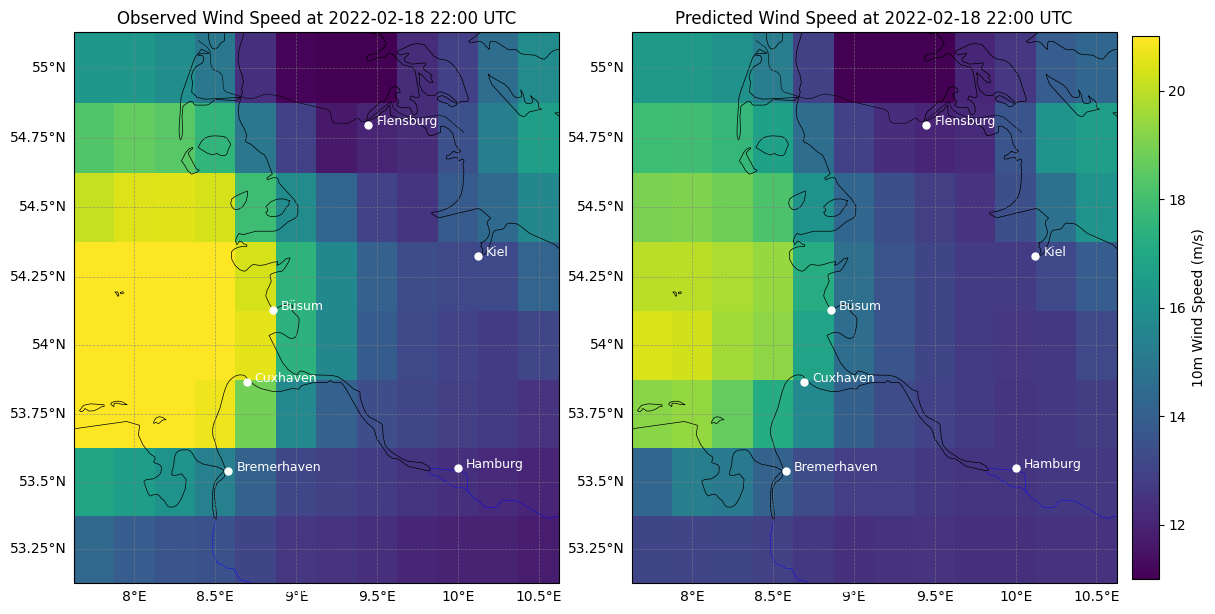

In [23]:
plot_wind_speed_comparison(
    predictions_path="../data/prediction_zeynep_22/predictions/zeynep_22_prediction_graphcast_operational.nc",
    input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_operational.nc",
    time_label="2022-02-18 22:00 UTC"
)

# Tests

In [25]:
input_path_small="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
input_path_operational="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_operational.nc"

original_prediction_path_small="../data/prediction_zeynep_22/predictions/zeynep_22_prediction_graphcast_small.nc"
original_prediction_path_operational="../data/prediction_zeynep_22/predictions/zeynep_22_prediction_graphcast_operational.nc"

In [28]:
# Define file path and region
region_lat = slice(55.0, 53.0)  # North to South
region_lon = slice(8, 10)   # West to East

# Load the dataset
ds = xr.open_dataset(input_path_operational)

# Find the index for 22:00 UTC
time_sel = int(np.where(ds.time.dt.hour == 22)[0][0])

# Select u and v components at 22:00
u10 = ds["10m_u_component_of_wind"].isel(time=time_sel)
v10 = ds["10m_v_component_of_wind"].isel(time=time_sel)

# Compute wind speed
wind_speed = np.sqrt(u10**2 + v10**2)

# Select region and compute mean
regional_mean = wind_speed.sel(lat=region_lat, lon=region_lon).mean().item()

print(f"Mean 10m wind speed at 22:00 UTC over North Germany: {regional_mean:.2f} m/s")


Mean 10m wind speed at 22:00 UTC over North Germany: 15.22 m/s


In [29]:
# Define the North Germany box
region_lat = slice(55.0, 53.0)  # from 55° N down to 53° N
region_lon = slice(8, 10)   # from 7.5° E to 10.5° E

# Load your single‐timestep prediction (replace with your own path or Dataset object)
pred = xr.open_dataset(original_prediction_path_operational)  # this dataset has only one time index

# Since there is exactly one time step, just pick time index 0
u10 = pred["10m_u_component_of_wind"].isel(time=0)
v10 = pred["10m_v_component_of_wind"].isel(time=0)

# Compute 10 m wind speed
wind_speed_10m = np.sqrt(u10**2 + v10**2)

# Restrict to the North Germany box and take the spatial mean
regional_mean = wind_speed_10m.sel(lat=region_lat, lon=region_lon).mean().item()

print(f"Mean 10 m wind speed (prediction time) over North Germany: {regional_mean:.2f} m/s")


Mean 10 m wind speed (prediction time) over North Germany: 14.24 m/s


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_17421/1053189026.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  pred = xr.open_dataset(original_prediction_path_operational)  # this dataset has only one time index


In [26]:
# Define file path and region
region_lat = slice(55.0, 53.0)  # North to South
region_lon = slice(8, 10)   # West to East

# Load the dataset
ds = xr.open_dataset(input_path_small)

# Find the index for 22:00 UTC
time_sel = int(np.where(ds.time.dt.hour == 22)[0][0])

# Select u and v components at 22:00
u10 = ds["10m_u_component_of_wind"].isel(time=time_sel)
v10 = ds["10m_v_component_of_wind"].isel(time=time_sel)

# Compute wind speed
wind_speed = np.sqrt(u10**2 + v10**2)

# Select the region
region = wind_speed.sel(lat=region_lat, lon=region_lon)

# Compute mean
regional_mean = region.mean().item()

# Report results
print(f"Mean 10m wind speed at 22:00 UTC over North Germany: {regional_mean:.2f} m/s")

# How many grid points were used?
n_lat = region.sizes['lat']
n_lon = region.sizes['lon']
n_points = region.size  # total number of lat/lon combinations
print(f"Grid points used: {n_lat} latitudes × {n_lon} longitudes = {n_points} points")

# Optional: print coordinates
lat_vals = region.lat.values
lon_vals = region.lon.values
print("Latitude values:", lat_vals)
print("Longitude values:", lon_vals)

# Optional: all (lat, lon) pairs
print("\nAll (lat, lon) grid points used:")
for lat in lat_vals:
    for lon in lon_vals:
        print(f"({lat:.3f}, {lon:.3f})")


Mean 10m wind speed at 22:00 UTC over North Germany: 14.72 m/s
Grid points used: 3 latitudes × 3 longitudes = 9 points
Latitude values: [55. 54. 53.]
Longitude values: [ 8.  9. 10.]

All (lat, lon) grid points used:
(55.000, 8.000)
(55.000, 9.000)
(55.000, 10.000)
(54.000, 8.000)
(54.000, 9.000)
(54.000, 10.000)
(53.000, 8.000)
(53.000, 9.000)
(53.000, 10.000)


In [27]:
# Define the North Germany box
region_lat = slice(55.0, 53.0)  # from 55° N down to 53° N
region_lon = slice(8, 10)   # from 7.5° E to 10.5° E

# Load the single‐timestep prediction dataset
pred = xr.open_dataset(original_prediction_path_small)

# Pick the only time step
u10 = pred["10m_u_component_of_wind"].isel(time=0)
v10 = pred["10m_v_component_of_wind"].isel(time=0)

# Compute 10 m wind speed
wind_speed_10m = np.sqrt(u10**2 + v10**2)

# Restrict to the North Germany box
region = wind_speed_10m.sel(lat=region_lat, lon=region_lon)

# Compute spatial mean
regional_mean = region.mean().item()

# Report mean
print(f"Mean 10 m wind speed (prediction time) over North Germany: {regional_mean:.2f} m/s")

# Report grid shape
n_lat = region.sizes['lat']
n_lon = region.sizes['lon']
n_total = region.size
print(f"Grid points used: {n_lat} latitudes × {n_lon} longitudes = {n_total} points")

# List coordinate values
lat_vals = region.lat.values
lon_vals = region.lon.values
print("Latitude values:", lat_vals)
print("Longitude values:", lon_vals)

# Optional: full (lat, lon) list
print("\nAll (lat, lon) grid points used:")
for lat in lat_vals:
    for lon in lon_vals:
        print(f"({lat:.3f}, {lon:.3f})")


Mean 10 m wind speed (prediction time) over North Germany: 13.36 m/s
Grid points used: 3 latitudes × 3 longitudes = 9 points
Latitude values: [55. 54. 53.]
Longitude values: [ 8.  9. 10.]

All (lat, lon) grid points used:
(55.000, 8.000)
(55.000, 9.000)
(55.000, 10.000)
(54.000, 8.000)
(54.000, 9.000)
(54.000, 10.000)
(53.000, 8.000)
(53.000, 9.000)
(53.000, 10.000)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_17421/2858415941.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  pred = xr.open_dataset(original_prediction_path_small)


In [31]:
# Load ERA5 and prediction datasets
era5 = xr.open_dataset(input_path_operational)
pred = xr.open_dataset(original_prediction_path_operational)

# Define region (North Germany box)
region_lat = slice(55.0, 53.0)  # from 55°N down to 53°N
region_lon = slice(8.0, 10.0)   # from 8°E to 10°E

# --- Select time ---

# Use 22:00 UTC from ERA5
time_sel = int(np.where(era5.time.dt.hour == 22)[0][0])

# --- Compute 10m wind speed ---

# ERA5 wind components at 22:00
u_obs = era5["10m_u_component_of_wind"].isel(time=time_sel)
v_obs = era5["10m_v_component_of_wind"].isel(time=time_sel)
wind_obs = np.sqrt(u_obs**2 + v_obs**2)

# Prediction (only one timestep)
u_pred = pred["10m_u_component_of_wind"].isel(time=0)
v_pred = pred["10m_v_component_of_wind"].isel(time=0)
wind_pred = np.sqrt(u_pred**2 + v_pred**2)

# --- Select region ---
obs_region = wind_obs.sel(lat=region_lat, lon=region_lon)
pred_region = wind_pred.sel(lat=region_lat, lon=region_lon)

# --- Calculate errors ---
error = pred_region - obs_region
mae = np.abs(error).mean(skipna=True).item()
rmse = np.sqrt((error**2).mean(skipna=True)).item()

# --- Report results ---
print(f"Mean Absolute Error (MAE) over North Germany:  {mae:.2f} m/s")
print(f"Root Mean Square Error (RMSE) over North Germany: {rmse:.2f} m/s")

# --- Optional: diagnostics ---
print(f"\nGrid shape used: {obs_region.sizes['lat']} latitudes × {obs_region.sizes['lon']} longitudes")
print(f"Total grid points: {obs_region.size}")


Mean Absolute Error (MAE) over North Germany:  1.07 m/s
Root Mean Square Error (RMSE) over North Germany: 1.59 m/s

Grid shape used: 9 latitudes × 9 longitudes
Total grid points: 81


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_17421/1867751005.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  pred = xr.open_dataset(original_prediction_path_operational)
